In [5]:
import os

import pandas as pd
import re

# Завантажуємо наш щойно створений датасет (перевір шлях, якщо він інший)
path = os.path.join('..', 'data', 'processed', 'sc_dataset.csv')
df = pd.read_csv(path)

# Беремо всі речення, коротші за 15 символів
short_sents = df[df['text'].str.len() < 15]

print("📊 --- EDA КОРОТКИХ РЕЧЕНЬ ---")
print(f"Всього речень у датасеті: {len(df)}")
print(f"Коротких речень (< 15 символів): {len(short_sents)} ({len(short_sents)/len(df):.2%})")

# Перевіряємо гіпотезу про розірвані списки ("1.", "2.", "а)")
list_breaks = df[df['text'].str.match(r'^(\d+\.|[a-zA-Zа-яА-Я]\)|\-)$', na=False)]
print(f"Речень, що виглядають як залишки списків: {len(list_breaks)}")

print("\n🔍 Приклади коротких речень (випадкові 20):")
# Виводимо унікальні короткі речення, щоб оцінити їх візуально
for text in short_sents['text'].unique()[:20]:
    print(f"[{len(text)} симв.] '{text}'")

📊 --- EDA КОРОТКИХ РЕЧЕНЬ ---
Всього речень у датасеті: 15646
Коротких речень (< 15 символів): 356 (2.28%)
Речень, що виглядають як залишки списків: 14

🔍 Приклади коротких речень (випадкові 20):
[14 симв.] 'Trump tweeted.'
[8 симв.] 'Perhaps.'
[1 симв.] '"'
[13 симв.] 'God Bless! !”'
[10 симв.] 'one wrote.'
[7 симв.] 'Trenton'
[5 симв.] 'Wait!'
[5 симв.] 'Give.'
[13 симв.] 'Me. A. Break.'
[6 симв.] '“1917:'
[14 симв.] 'You write well'
[13 симв.] 'Kerry On Edge'
[7 симв.] 'Really?'
[10 симв.] 'Oh Muslim!'
[14 симв.] 'The Secret ...'
[14 симв.] 'Dalton Trumbo.'
[7 симв.] '58 dead'
[13 симв.] 'Or something.'
[9 симв.] 'And mean.'
[13 симв.] 'They said no.'


In [ ]:
import os
import pickle
import numpy as np
import re
from collections import defaultdict
from huggingface_hub import hf_hub_download
from sklearn.metrics import precision_score, recall_score, fbeta_score

# ==========================================
# 1. ЗАВАНТАЖЕННЯ ДАНИХ (Щоб не було NameError)
# ==========================================
HF_TOKEN = os.getenv("HF_TOKEN")
REPO_ID = "hannusia123123/si-oof"

print("☁️ Завантажуємо OOF...")
roberta_path = hf_hub_download(repo_id=REPO_ID, filename="oof_roberta.pkl", repo_type="dataset", token=HF_TOKEN)
electra_path = hf_hub_download(repo_id=REPO_ID, filename="oof_electra.pkl", repo_type="dataset", token=HF_TOKEN)

with open(roberta_path, "rb") as f: oof_rob = pickle.load(f)
with open(electra_path, "rb") as f: oof_ele = pickle.load(f)

# Групуємо
rob_by_article = defaultdict(list)
for x in oof_rob: rob_by_article[x["article_id"]].append(x)
ele_by_article = defaultdict(list)
for x in oof_ele: ele_by_article[x["article_id"]].append(x)

unique_articles = list(rob_by_article.keys())

# Вирівнюємо по символах
y_true_all, p_rob_all, p_ele_all = [], [], []
article_char_bounds = {} # Збережемо межі статей, щоб потім відновити текст
current_idx = 0

for art_id in unique_articles:
    max_char = max([end for w in rob_by_article[art_id] for start, end in w["offset_mapping"]] + [0])
    if max_char == 0: continue

    c_prob_rob = np.zeros((max_char, 3))
    c_count_rob = np.zeros(max_char)
    c_prob_ele = np.zeros((max_char, 3))
    c_count_ele = np.zeros(max_char)
    c_labels = np.full(max_char, -100, dtype=int)

    for w in rob_by_article[art_id]:
        for i, (s, e) in enumerate(w["offset_mapping"]):
            if s == e: continue
            c_prob_rob[s:e] += w["probs"][i]
            c_count_rob[s:e] += 1
            if w["labels"][i] != -100: c_labels[s:e] = w["labels"][i]

    for w in ele_by_article[art_id]:
        for i, (s, e) in enumerate(w["offset_mapping"]):
            if s == e: continue
            c_prob_ele[s:e] += w["probs"][i]
            c_count_ele[s:e] += 1

    mask_rob = c_count_rob > 0
    c_prob_rob[mask_rob] /= c_count_rob[mask_rob][:, None]
    
    mask_ele = c_count_ele > 0
    c_prob_ele[mask_ele] /= c_count_ele[mask_ele][:, None]

    valid_mask = (c_labels != -100) & mask_rob & mask_ele
    
    # Записуємо глобальні індекси для кожної статті
    length = np.sum(valid_mask)
    article_char_bounds[art_id] = (current_idx, current_idx + length)
    current_idx += length

    y_true_all.extend(c_labels[valid_mask])
    p_rob_all.extend(c_prob_rob[valid_mask])
    p_ele_all.extend(c_prob_ele[valid_mask])

y_true = np.array(y_true_all)
p_rob = np.array(p_rob_all)
p_ele = np.array(p_ele_all)

# ==========================================
# 2. АНСАМБЛЬ ТА ОЦІНКА
# ==========================================
w_rob, w_ele = 0.6, 0.4
thresh1, thresh2 = 0.50, 0.55

ensembled_probs = (p_rob * w_rob) + (p_ele * w_ele)
raw_preds = np.zeros_like(y_true)

mask1 = ensembled_probs[:, 1] > thresh1
mask2 = ensembled_probs[:, 2] > thresh2
raw_preds[mask1] = 1
raw_preds[mask2] = 2
overlap = mask1 & mask2
raw_preds[overlap] = np.argmax(ensembled_probs[overlap, 1:], axis=1) + 1

# ==========================================
# 3. НАОЧНЕ ДОСЛІДЖЕННЯ: Чи розриває модель слова?
# ==========================================
import json
print("\n🔍 ДОСЛІДЖЕННЯ: Завантажуємо оригінальний текст для аналізу...")
with open('../data/processed/si_dataset.json', 'r', encoding='utf-8') as f:
    orig_data = json.load(f)
text_dict = {item['article_id']: item['text'] for item in orig_data}

# Беремо першу статтю для перевірки
sample_art = unique_articles[0]
start_idx, end_idx = article_char_bounds[sample_art]

sample_text = text_dict[sample_art]
sample_preds = raw_preds[start_idx:end_idx]

print(f"\n📝 АНАЛІЗ ФРАГМЕНТАЦІЇ ДЛЯ СТАТТІ: {sample_art}")
print("-" * 50)

# Шукаємо "рвані" слова (де модель змінила думку посеред слова)
# Простий розбір по словах через регулярні вирази
for match in re.finditer(r'\b\w+\b', sample_text):
    word_start = match.start()
    word_end = match.end()
    
    if word_end <= len(sample_preds):
        word_preds = sample_preds[word_start:word_end]
        unique_preds = np.unique(word_preds)
        
        # Якщо в одному слові є і 0, і 1 (або 2) — модель РОЗІРВАЛА СЛОВО!
        if len(unique_preds) > 1:
            print(f"❌ Розірване слово: '{match.group()}'")
            print(f"   Символи: {list(match.group())}")
            print(f"   Класи:   {word_preds.tolist()}")
            
print("-" * 50)

# ==========================================
# 4. ФІЛЬТР "WORD BOUNDARY SNAPPING" (Вирівнювання по словах)
# ==========================================
def snap_to_word_boundaries(text, preds_array):
    """
    Твоя ідея: якщо хоч один символ у слові названо пропагандою - 
    все слово стає пропагандою.
    """
    snapped_preds = preds_array.copy()
    
    # Знаходимо всі слова в тексті
    for match in re.finditer(r'\b\w+\b', text):
        start, end = match.start(), match.end()
        if end <= len(snapped_preds):
            word_preds = snapped_preds[start:end]
            
            # Якщо є пропаганда (клас 1 або 2)
            if 1 in word_preds or 2 in word_preds:
                # Беремо найпопулярніший клас пропаганди в цьому слові
                propaganda_classes = [p for p in word_preds if p != 0]
                majority_class = max(set(propaganda_classes), key=propaganda_classes.count)
                
                # "Захоплюємо" все слово
                snapped_preds[start:end] = majority_class
                
    return snapped_preds

print("\n✨ Застосовуємо Word Boundary Snapping до всього датасету...")
snapped_preds_all = np.zeros_like(raw_preds)

for art_id in unique_articles:
    start_idx, end_idx = article_char_bounds[art_id]
    art_text = text_dict[art_id]
    art_preds = raw_preds[start_idx:end_idx]
    
    # Вирівнюємо по словах для кожної статті
    snapped_preds_all[start_idx:end_idx] = snap_to_word_boundaries(art_text, art_preds)

# Рахуємо метрики ПІСЛЯ зшивання слів
prec_snap = precision_score(y_true, snapped_preds_all, labels=[1, 2], average="micro", zero_division=0)
rec_snap = recall_score(y_true, snapped_preds_all, labels=[1, 2], average="micro", zero_division=0)
f05_snap = fbeta_score(y_true, snapped_preds_all, beta=0.5, labels=[1, 2], average="micro", zero_division=0)

print("="*50)
print(f"🎯 Precision ПІСЛЯ Word Snapping: {prec_snap:.4f}")
print(f"🔍 Recall ПІСЛЯ Word Snapping: {rec_snap:.4f}")
print(f"⚖️ F0.5 ПІСЛЯ Word Snapping: {f05_snap:.4f}")
print("="*50)

d:\anykn\python\propaganda-detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


☁️ Завантажуємо OOF...

🔍 ДОСЛІДЖЕННЯ: Завантажуємо оригінальний текст для аналізу...

📝 АНАЛІЗ ФРАГМЕНТАЦІЇ ДЛЯ СТАТТІ: article111111111
--------------------------------------------------
❌ Розірване слово: 'between'
   Символи: ['b', 'e', 't', 'w', 'e', 'e', 'n']
   Класи:   [0, 0, 2, 2, 0, 0, 0]
❌ Розірване слово: 'and'
   Символи: ['a', 'n', 'd']
   Класи:   [0, 0, 2]
❌ Розірване слово: 'every'
   Символи: ['e', 'v', 'e', 'r', 'y']
   Класи:   [2, 0, 0, 0, 0]
❌ Розірване слово: 'and'
   Символи: ['a', 'n', 'd']
   Класи:   [2, 0, 0]
❌ Розірване слово: 'over'
   Символи: ['o', 'v', 'e', 'r']
   Класи:   [2, 2, 2, 0]
❌ Розірване слово: 'had'
   Символи: ['h', 'a', 'd']
   Класи:   [0, 0, 2]
❌ Розірване слово: 'helped'
   Символи: ['h', 'e', 'l', 'p', 'e', 'd']
   Класи:   [2, 2, 2, 0, 0, 0]
❌ Розірване слово: 'causes'
   Символи: ['c', 'a', 'u', 's', 'e', 's']
   Класи:   [0, 0, 0, 2, 2, 2]
❌ Розірване слово: 'plague'
   Символи: ['p', 'l', 'a', 'g', 'u', 'e']
   Класи:   [2, 0, 0, 0


📊 Малюємо матрицю плутанини для Word Snapping...


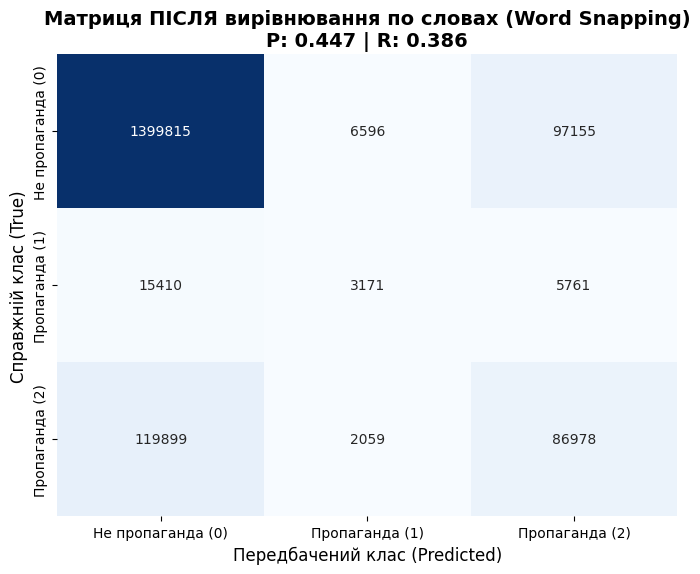

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n📊 Малюємо матрицю плутанини для Word Snapping...")

# Рахуємо матрицю плутанини для зшитих слів
cm_snap = confusion_matrix(y_true, snapped_preds_all, labels=[0, 1, 2])

# Малюємо теплову карту
plt.figure(figsize=(8, 6))
sns.heatmap(cm_snap, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Не пропаганда (0)', 'Пропаганда (1)', 'Пропаганда (2)'],
            yticklabels=['Не пропаганда (0)', 'Пропаганда (1)', 'Пропаганда (2)'])

plt.title(f"Матриця ПІСЛЯ вирівнювання по словах (Word Snapping)\nP: {prec_snap:.3f} | R: {rec_snap:.3f}", 
          fontsize=14, fontweight='bold')
plt.ylabel('Справжній клас (True)', fontsize=12)
plt.xlabel('Передбачений клас (Predicted)', fontsize=12)
plt.show()